# DEEPDSP-AMC — Nhận dạng điều chế số tự động trong kênh vô tuyến nhiễu

**Đồ án lấy điểm cộng — Thực hành Xử lý tín hiệu số, lớp 24DTV_DKD2**  
**Giảng viên:** ThS. Huỳnh Quốc Thịnh  
**Sinh viên:** Lương Hải Long — **MSSV:** 22207056  
**Thời điểm hoàn thiện:** Tháng 08 năm 2026  
**Video demo:** [https://youtu.be/yl5Sk6plWXg](https://youtu.be/yl5Sk6plWXg)

Notebook xây dựng một chuỗi xử lý tín hiệu số và học máy hoàn chỉnh: sinh tín hiệu
I/Q của sáu kiểu điều chế, tạo dạng xung RRC, mô phỏng kênh AWGN cùng sai lệch pha,
tần số và đa đường nhẹ, trích đặc trưng DSP, huấn luyện Random Forest và CNN 1-D,
sau đó đánh giá theo SNR. Tất cả dữ liệu được sinh cục bộ bằng hạt giống cố định;
không cần tải bộ dữ liệu ngoài.

## 1. Câu hỏi nghiên cứu và tiêu chí kỹ thuật

**RQ.** Với khung tín hiệu I/Q dài 256 mẫu, trong dải SNR từ $-12$ đến $18$ dB,
mô hình CNN 1-D gọn nhẹ sử dụng biểu diễn I/Q–biên độ–sai phân pha có cải thiện
macro-F1 so với bộ phân loại Random Forest dựa trên đặc trưng DSP hay không?

Sáu lớp được khảo sát: **BPSK, QPSK, 8PSK, 16QAM, 2FSK, 4FSK**. SNR chỉ dùng
để tạo và phân tầng dữ liệu, tuyệt đối không được đưa vào đầu vào bộ phân loại.

Mô hình kênh rời rạc:

$$r[n] = e^{j(2\pi\Delta f n + \phi_0)}\,(s*h)[n] + w[n],$$

với $w[n]\sim\mathcal{CN}(0,\sigma_w^2)$ và
$\mathrm{SNR}_{\mathrm{dB}}=10\log_{10}(P_s/P_w)$.

In [1]:
from __future__ import annotations

import json
import math
import os
import platform
import random
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from scipy import signal, stats
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 22207056
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.set_num_threads(max(1, min(8, os.cpu_count() or 1)))

ROOT = Path.cwd()
FIG_DIR = ROOT / "assets" / "figures"
ARTIFACT_DIR = ROOT / "artifacts"
FIG_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 220,
        "font.family": "DejaVu Sans",
        "font.size": 10.5,
        "axes.titlesize": 11.5,
        "axes.labelsize": 10.5,
        "axes.grid": True,
        "grid.alpha": 0.22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
    }
)
sns.set_palette("colorblind")

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | SciPy {scipy.__version__}")
print(f"scikit-learn {sklearn.__version__} | PyTorch {torch.__version__}")
print(f"Thiết bị huấn luyện: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print(f"Thư mục làm việc: {ROOT}")

Python 3.14.3 | NumPy 2.4.4 | SciPy 1.17.1
scikit-learn 1.9.0 | PyTorch 2.11.0+cpu
Thiết bị huấn luyện: CPU
Thư mục làm việc: D:\ThucHanhXuLyTinHieuSo\DoAnDiemCong_AMC_22207056


## 2. Cấu hình thí nghiệm

Mỗi tổ hợp lớp–SNR có cùng số mẫu. Việc chia tập dựa trên nhãn ghép
`(modulation, SNR)` để duy trì đúng phân bố ở train/validation/test. Các khung
được sinh độc lập; không có phép cắt chồng lấn từ một bản ghi dài nên tránh rò rỉ
dữ liệu do các đoạn tín hiệu gần nhau.

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    classes: tuple[str, ...] = ("BPSK", "QPSK", "8PSK", "16QAM", "2FSK", "4FSK")
    snr_db: tuple[int, ...] = tuple(range(-12, 19, 3))
    frames_per_class_snr: int = 100
    frame_len: int = 256
    samples_per_symbol: int = 8
    rrc_rolloff: float = 0.35
    rrc_span_symbols: int = 8
    test_fraction: float = 0.20
    val_fraction_of_train: float = 0.15
    batch_size: int = 256
    max_epochs: int = 22
    patience: int = 5
    learning_rate: float = 1.5e-3


CFG = ExperimentConfig()
N_CLASSES = len(CFG.classes)
TOTAL_FRAMES = N_CLASSES * len(CFG.snr_db) * CFG.frames_per_class_snr
display(pd.DataFrame([asdict(CFG)]).T.rename(columns={0: "Giá trị"}))
print(f"Tổng số khung I/Q: {TOTAL_FRAMES:,}")

,Giá trị
classes,"(BPSK, QPSK, 8PSK, 16QAM, 2FSK, 4FSK)"
snr_db,"(-12, -9, -6, -3, 0, 3, 6, 9, 12, 15, 18)"
frames_per_class_snr,100
frame_len,256
samples_per_symbol,8
rrc_rolloff,0.35
rrc_span_symbols,8
test_fraction,0.2
val_fraction_of_train,0.15
batch_size,256


Tổng số khung I/Q: 6,600


## 3. Bộ sinh tín hiệu và mô hình kênh

Với PSK/QAM, chuỗi ký hiệu được chèn không và lọc bởi bộ tạo dạng xung
root-raised-cosine (RRC). Hai lớp FSK dùng pha liên tục. Sau đó khung tín hiệu
đi qua kênh hai tia nhẹ, sai lệch tần số sóng mang (CFO), lệch pha và AWGN.

Xung RRC tại thời điểm chuẩn hóa $t$:

$$
g(t)=\frac{\sin[\pi t(1-\beta)]+4\beta t\cos[\pi t(1+\beta)]}
{\pi t\,[1-(4\beta t)^2]},
$$

trong đó $\beta$ là hệ số roll-off. Các điểm suy biến được xử lý bằng giới hạn
giải tích, không thay bằng giá trị tùy ý.

In [3]:
def rrc_taps(beta: float, sps: int, span_symbols: int) -> np.ndarray:
    """Sinh bộ lọc RRC năng lượng đơn vị, chiều dài span*sps+1."""
    n = np.arange(-span_symbols * sps / 2, span_symbols * sps / 2 + 1)
    t = n / sps
    taps = np.empty_like(t, dtype=np.float64)
    for i, ti in enumerate(t):
        if np.isclose(ti, 0.0):
            taps[i] = 1.0 + beta * (4.0 / np.pi - 1.0)
        elif beta > 0 and np.isclose(abs(ti), 1.0 / (4.0 * beta)):
            taps[i] = (beta / np.sqrt(2.0)) * (
                (1.0 + 2.0 / np.pi) * np.sin(np.pi / (4.0 * beta))
                + (1.0 - 2.0 / np.pi) * np.cos(np.pi / (4.0 * beta))
            )
        else:
            num = np.sin(np.pi * ti * (1.0 - beta))
            num += 4.0 * beta * ti * np.cos(np.pi * ti * (1.0 + beta))
            den = np.pi * ti * (1.0 - (4.0 * beta * ti) ** 2)
            taps[i] = num / den
    return (taps / np.sqrt(np.sum(taps**2))).astype(np.float32)


RRC = rrc_taps(CFG.rrc_rolloff, CFG.samples_per_symbol, CFG.rrc_span_symbols)


def constellation_symbols(kind: str, count: int, rng: np.random.Generator) -> np.ndarray:
    if kind == "BPSK":
        return rng.choice(np.array([-1.0, 1.0], dtype=np.complex64), count)
    if kind in {"QPSK", "8PSK"}:
        order = 4 if kind == "QPSK" else 8
        indices = rng.integers(0, order, count)
        offset = np.pi / 4 if kind == "QPSK" else 0.0
        return np.exp(1j * (2 * np.pi * indices / order + offset)).astype(np.complex64)
    if kind == "16QAM":
        levels = np.array([-3, -1, 1, 3], dtype=np.float32)
        i = rng.choice(levels, count)
        q = rng.choice(levels, count)
        return ((i + 1j * q) / np.sqrt(10.0)).astype(np.complex64)
    raise ValueError(f"Không hỗ trợ chòm sao {kind}")


def generate_clean_frame(kind: str, rng: np.random.Generator) -> np.ndarray:
    """Tạo khung complex baseband đủ dài rồi cắt phần giữa để bỏ quá độ lọc."""
    n = CFG.frame_len
    sps = CFG.samples_per_symbol
    margin_symbols = CFG.rrc_span_symbols + 6
    symbol_count = math.ceil(n / sps) + 2 * margin_symbols

    if kind in {"BPSK", "QPSK", "8PSK", "16QAM"}:
        symbols = constellation_symbols(kind, symbol_count, rng)
        upsampled = np.zeros(symbol_count * sps, dtype=np.complex64)
        upsampled[::sps] = symbols
        shaped = signal.fftconvolve(upsampled, RRC, mode="same")
        center = len(shaped) // 2
        frame = shaped[center - n // 2 : center + n // 2]
    else:
        order = 2 if kind == "2FSK" else 4
        tones = np.array([-0.080, 0.080]) if order == 2 else np.array([-0.135, -0.045, 0.045, 0.135])
        symbols = rng.integers(0, order, symbol_count)
        inst_freq = np.repeat(tones[symbols], sps)
        phase = 2.0 * np.pi * np.cumsum(inst_freq)
        shaped = np.exp(1j * phase)
        center = len(shaped) // 2
        frame = shaped[center - n // 2 : center + n // 2]

    power = np.mean(np.abs(frame) ** 2)
    return (frame / np.sqrt(power + 1e-12)).astype(np.complex64)


def apply_channel(clean: np.ndarray, snr_db: float, rng: np.random.Generator) -> np.ndarray:
    n = np.arange(len(clean), dtype=np.float32)
    # Đa đường nhẹ: tia thứ hai trễ 1–4 mẫu và suy hao không quá -14 dB.
    delay = int(rng.integers(1, 5))
    echo_amp = rng.uniform(0.0, 0.20)
    echo_phase = rng.uniform(-np.pi, np.pi)
    h = np.zeros(delay + 1, dtype=np.complex64)
    h[0] = 1.0
    h[-1] = echo_amp * np.exp(1j * echo_phase)
    faded = signal.lfilter(h, [1.0], clean)

    cfo = rng.uniform(-0.0020, 0.0020)  # cycles/sample
    phase0 = rng.uniform(-np.pi, np.pi)
    shifted = faded * np.exp(1j * (2.0 * np.pi * cfo * n + phase0))
    shifted = np.roll(shifted, int(rng.integers(0, CFG.samples_per_symbol)))

    signal_power = float(np.mean(np.abs(shifted) ** 2))
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))
    noise = np.sqrt(noise_power / 2.0) * (
        rng.standard_normal(len(clean)) + 1j * rng.standard_normal(len(clean))
    )
    received = shifted + noise
    received /= np.sqrt(np.mean(np.abs(received) ** 2) + 1e-12)
    return received.astype(np.complex64)


def make_dataset(seed: int = SEED) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    x = np.empty((TOTAL_FRAMES, CFG.frame_len), dtype=np.complex64)
    y = np.empty(TOTAL_FRAMES, dtype=np.int64)
    snr = np.empty(TOTAL_FRAMES, dtype=np.int16)
    row = 0
    for class_id, kind in enumerate(CFG.classes):
        for snr_db in CFG.snr_db:
            for _ in range(CFG.frames_per_class_snr):
                x[row] = apply_channel(generate_clean_frame(kind, rng), snr_db, rng)
                y[row] = class_id
                snr[row] = snr_db
                row += 1
    order = rng.permutation(row)
    return x[order], y[order], snr[order]


start = time.perf_counter()
X, y, snr_values = make_dataset()
print(f"Đã sinh {len(X):,} khung, kích thước {X.shape}, trong {time.perf_counter() - start:.2f} s")
assert np.isfinite(X.real).all() and np.isfinite(X.imag).all()
assert np.allclose(np.mean(np.abs(X) ** 2, axis=1), 1.0, atol=2e-5)

Đã sinh 6,600 khung, kích thước (6600, 256), trong 0.86 s


## 4. Kiểm tra trực quan tín hiệu

Ba cách nhìn bổ sung nhau được dùng: miền thời gian, mặt phẳng chòm sao và mật độ
phổ công suất. Chòm sao ở đây lấy trực tiếp từ chuỗi thu, chưa đồng bộ ký hiệu;
vì vậy độ xoay và độ dày đám mây là một phần của bài toán chứ không phải lỗi vẽ.

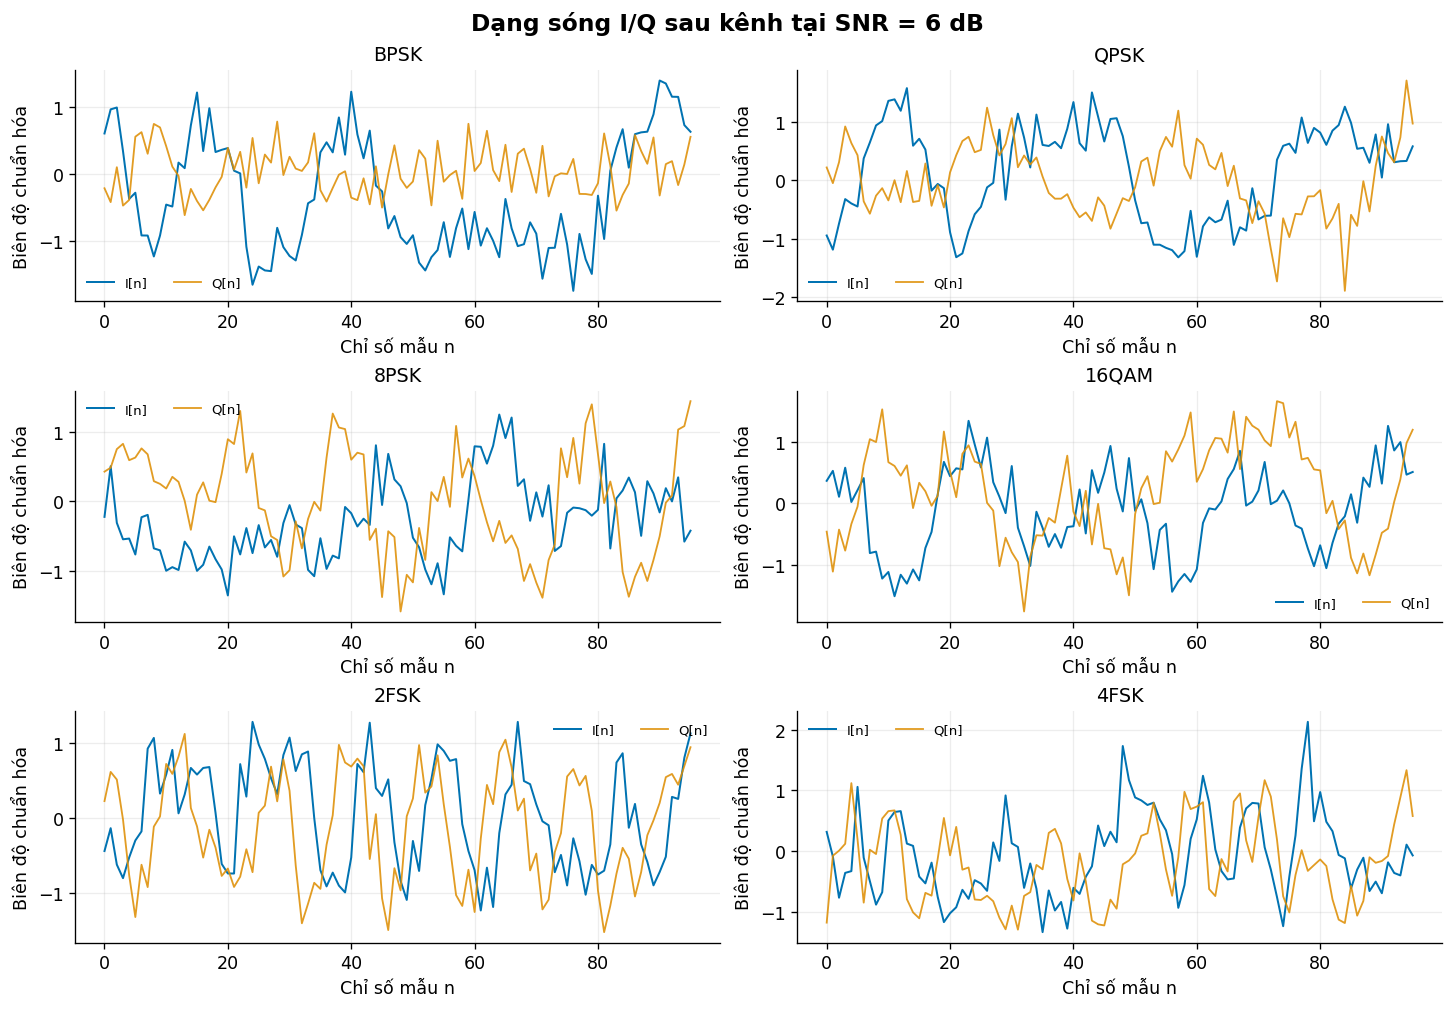

In [4]:
def representative_frame(kind: str, snr_db: int, seed_offset: int = 0) -> np.ndarray:
    rng = np.random.default_rng(SEED + 10_000 + seed_offset + CFG.classes.index(kind))
    return apply_channel(generate_clean_frame(kind, rng), snr_db, rng)


fig, axes = plt.subplots(3, 2, figsize=(12, 8.3), constrained_layout=True)
for ax, kind in zip(axes.flat, CFG.classes):
    z = representative_frame(kind, 6)
    ax.plot(z.real[:96], lw=1.2, label="I[n]")
    ax.plot(z.imag[:96], lw=1.1, label="Q[n]", alpha=0.88)
    ax.set_title(kind)
    ax.set_xlabel("Chỉ số mẫu n")
    ax.set_ylabel("Biên độ chuẩn hóa")
    ax.legend(ncol=2, fontsize=8)
fig.suptitle("Dạng sóng I/Q sau kênh tại SNR = 6 dB", fontsize=14, weight="bold")
fig.savefig(FIG_DIR / "01_iq_time_gallery.png", bbox_inches="tight")
plt.show()

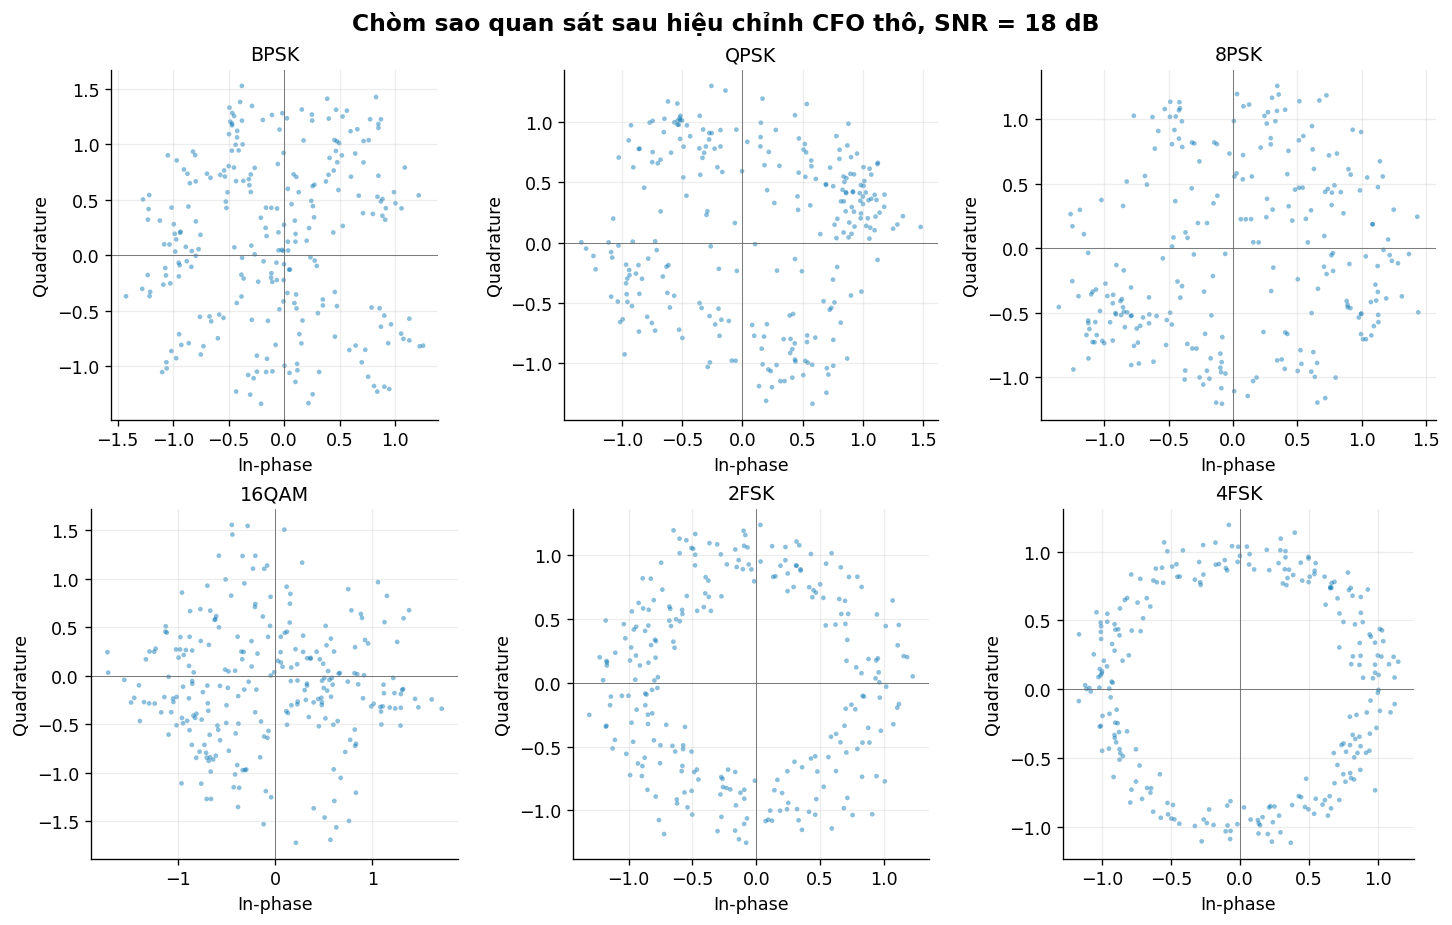

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7.6), constrained_layout=True)
for ax, kind in zip(axes.flat, CFG.classes):
    z = representative_frame(kind, 18, seed_offset=100)
    # Khử một phần pha tuyến tính để hình chòm sao đọc được hơn, không dùng cho classifier.
    dphi = np.angle(np.mean(z[1:] * np.conj(z[:-1])))
    corrected = z * np.exp(-1j * dphi * np.arange(len(z)))
    ax.scatter(corrected.real, corrected.imag, s=8, alpha=0.45, edgecolors="none")
    ax.axhline(0, color="0.4", lw=0.5)
    ax.axvline(0, color="0.4", lw=0.5)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(kind)
    ax.set_xlabel("In-phase")
    ax.set_ylabel("Quadrature")
fig.suptitle("Chòm sao quan sát sau hiệu chỉnh CFO thô, SNR = 18 dB", fontsize=14, weight="bold")
fig.savefig(FIG_DIR / "02_constellation_gallery.png", bbox_inches="tight")
plt.show()

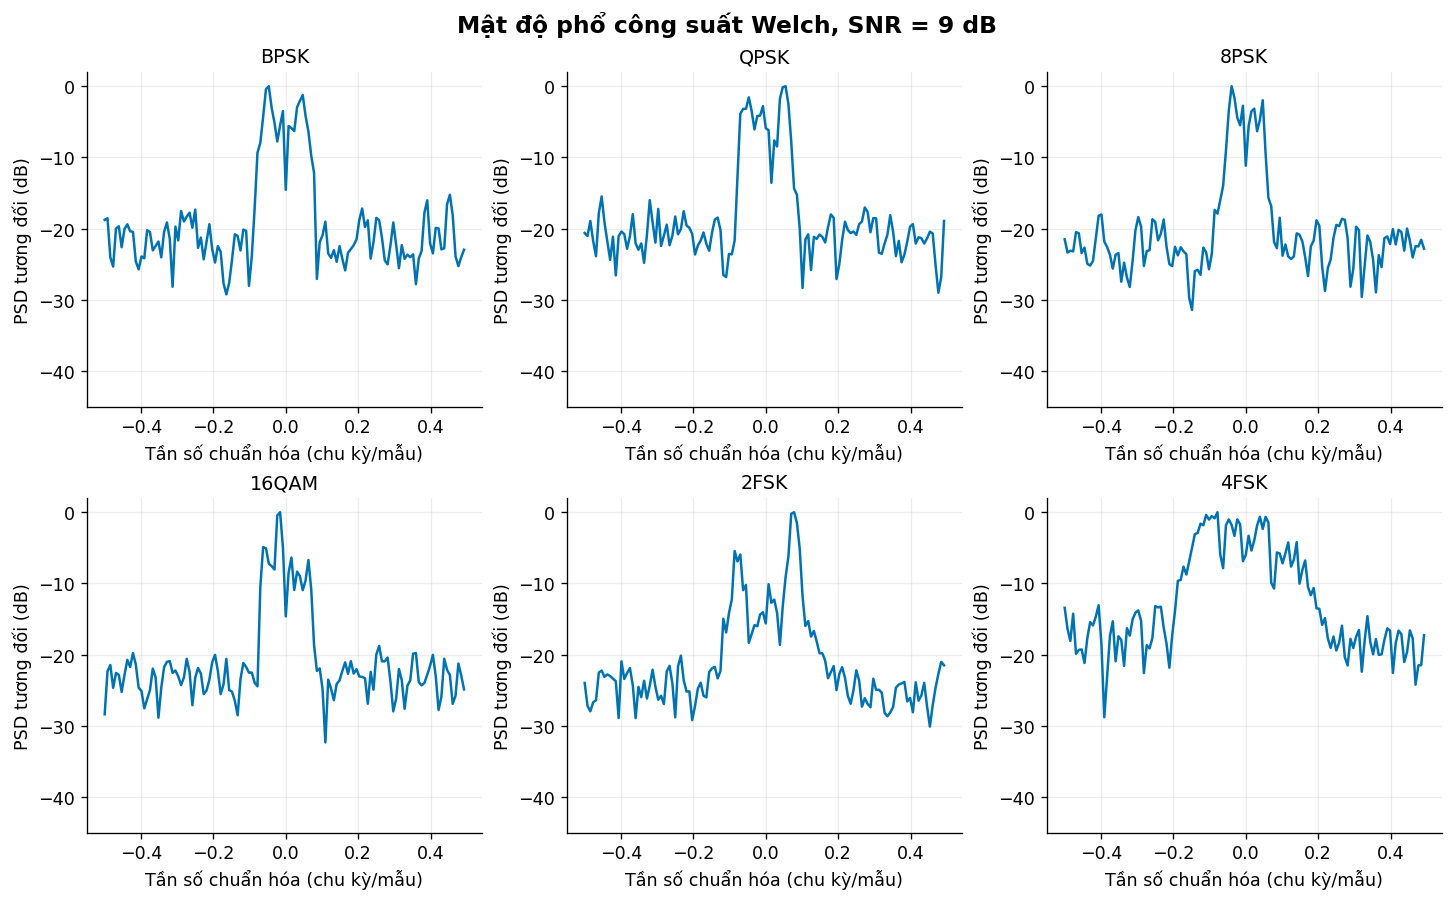

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7.4), constrained_layout=True)
for ax, kind in zip(axes.flat, CFG.classes):
    z = representative_frame(kind, 9, seed_offset=200)
    freq, psd = signal.welch(z, nperseg=128, noverlap=64, return_onesided=False)
    freq = np.fft.fftshift(freq)
    psd_db = 10 * np.log10(np.fft.fftshift(psd) + 1e-12)
    psd_db -= psd_db.max()
    ax.plot(freq, psd_db, lw=1.5)
    ax.set_ylim(-45, 2)
    ax.set_title(kind)
    ax.set_xlabel("Tần số chuẩn hóa (chu kỳ/mẫu)")
    ax.set_ylabel("PSD tương đối (dB)")
fig.suptitle("Mật độ phổ công suất Welch, SNR = 9 dB", fontsize=14, weight="bold")
fig.savefig(FIG_DIR / "03_psd_gallery.png", bbox_inches="tight")
plt.show()

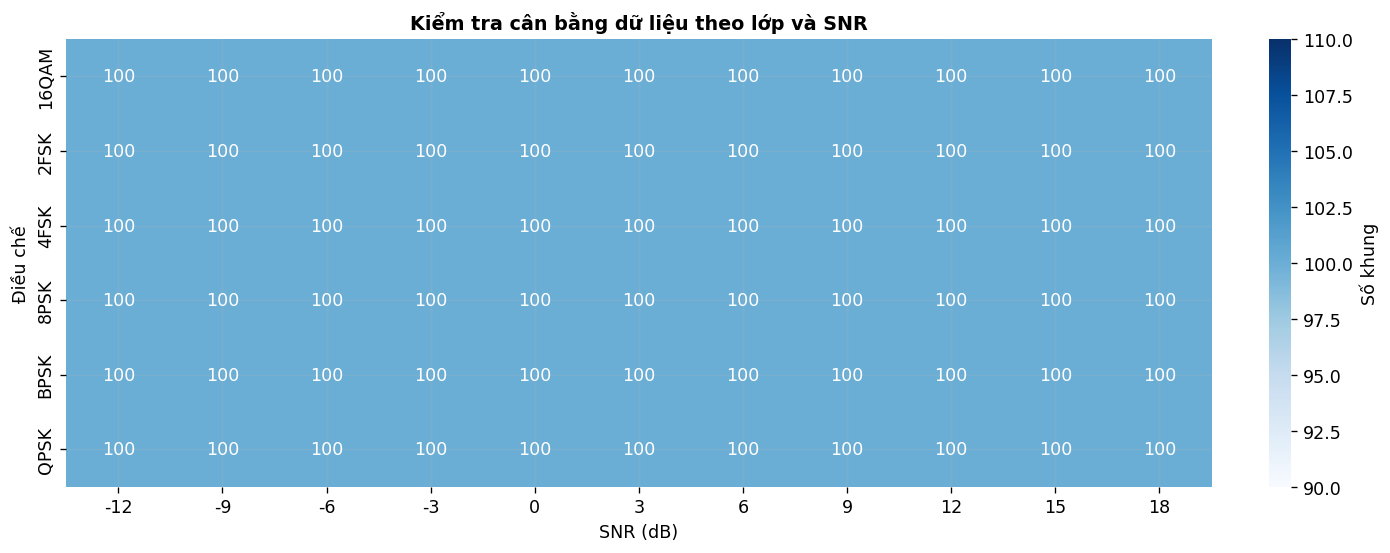

In [7]:
balance = (
    pd.DataFrame({"Điều chế": np.array(CFG.classes)[y], "SNR (dB)": snr_values})
    .value_counts()
    .rename("Số khung")
    .reset_index()
)
pivot_balance = balance.pivot(index="Điều chế", columns="SNR (dB)", values="Số khung")
fig, ax = plt.subplots(figsize=(11.5, 4.5), constrained_layout=True)
sns.heatmap(pivot_balance, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Số khung"}, ax=ax)
ax.set_title("Kiểm tra cân bằng dữ liệu theo lớp và SNR", weight="bold")
fig.savefig(FIG_DIR / "04_dataset_balance.png", bbox_inches="tight")
plt.show()

## 5. Đặc trưng DSP và mô hình học máy nền

Đặc trưng được chọn để mô tả ba miền:

- **biên độ:** hệ số biến thiên, độ lệch, độ nhọn, PAPR;
- **pha và moment phức:** $|E\{x^2\}|$, $|E\{x^4\}|$, $|E\{x^6\}|$,
  độ tập trung và độ phân tán của sai phân pha;
- **tần số:** entropy phổ, độ phẳng phổ, trọng tâm và độ rộng RMS.

Những đại lượng này không cần biết nhãn SNR và phần lớn bất biến với hệ số khuếch
đại chung. Random Forest đóng vai trò baseline ML có khả năng giải thích qua độ
quan trọng đặc trưng.

In [8]:
FEATURE_NAMES = [
    "amp_mean",
    "amp_std",
    "amp_cv",
    "amp_skew",
    "amp_kurtosis",
    "papr",
    "moment2_abs",
    "moment4_abs",
    "moment6_abs",
    "phase_diff_mean_abs",
    "phase_diff_std",
    "phase_concentration",
    "zero_cross_i",
    "zero_cross_q",
    "spectral_entropy",
    "spectral_flatness",
    "spectral_centroid",
    "spectral_spread",
]


def dsp_features(z: np.ndarray) -> np.ndarray:
    z = z / np.sqrt(np.mean(np.abs(z) ** 2) + 1e-12)
    amp = np.abs(z)
    dphase = np.angle(z[1:] * np.conj(z[:-1]))
    windowed = z * signal.windows.hann(len(z), sym=False)
    spectrum = np.abs(np.fft.fftshift(np.fft.fft(windowed))) ** 2
    p = spectrum / (np.sum(spectrum) + 1e-12)
    freq = np.fft.fftshift(np.fft.fftfreq(len(z)))
    centroid = float(np.sum(freq * p))
    spread = float(np.sqrt(np.sum(((freq - centroid) ** 2) * p)))
    signs_i = np.signbit(z.real)
    signs_q = np.signbit(z.imag)
    return np.array(
        [
            amp.mean(),
            amp.std(),
            amp.std() / (amp.mean() + 1e-12),
            stats.skew(amp, bias=False),
            stats.kurtosis(amp, fisher=True, bias=False),
            np.max(amp**2) / (np.mean(amp**2) + 1e-12),
            abs(np.mean(z**2)),
            abs(np.mean(z**4)),
            abs(np.mean(z**6)),
            abs(np.mean(dphase)),
            np.std(dphase),
            abs(np.mean(np.exp(1j * dphase))),
            np.mean(signs_i[1:] != signs_i[:-1]),
            np.mean(signs_q[1:] != signs_q[:-1]),
            -np.sum(p * np.log2(p + 1e-12)) / np.log2(len(p)),
            np.exp(np.mean(np.log(spectrum + 1e-12))) / (np.mean(spectrum) + 1e-12),
            centroid,
            spread,
        ],
        dtype=np.float32,
    )


start = time.perf_counter()
X_feat = np.vstack([dsp_features(row) for row in X])
print(f"Đã trích {X_feat.shape[1]} đặc trưng cho {len(X_feat):,} khung trong {time.perf_counter()-start:.2f} s")
assert X_feat.shape == (TOTAL_FRAMES, len(FEATURE_NAMES))
assert np.isfinite(X_feat).all()

strata = np.array([f"{label}_{snr}" for label, snr in zip(y, snr_values)])
all_indices = np.arange(len(y))
idx_trainval, idx_test = train_test_split(
    all_indices,
    test_size=CFG.test_fraction,
    random_state=SEED,
    stratify=strata,
)
idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=CFG.val_fraction_of_train,
    random_state=SEED,
    stratify=strata[idx_trainval],
)
assert set(idx_train).isdisjoint(idx_val)
assert set(idx_train).isdisjoint(idx_test)
assert set(idx_val).isdisjoint(idx_test)
print(f"Train/Validation/Test = {len(idx_train):,}/{len(idx_val):,}/{len(idx_test):,}")

rf_model = Pipeline(
    [
        ("scale", StandardScaler()),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=SEED,
            ),
        ),
    ]
)
start = time.perf_counter()
rf_model.fit(X_feat[idx_train], y[idx_train])
rf_train_seconds = time.perf_counter() - start
rf_prob = rf_model.predict_proba(X_feat[idx_test])
rf_pred = rf_prob.argmax(axis=1)
rf_accuracy = accuracy_score(y[idx_test], rf_pred)
rf_macro_f1 = f1_score(y[idx_test], rf_pred, average="macro")
print(f"RF: accuracy={rf_accuracy:.4f}, macro-F1={rf_macro_f1:.4f}, train={rf_train_seconds:.2f} s")

Đã trích 18 đặc trưng cho 6,600 khung trong 4.50 s
Train/Validation/Test = 4,488/792/1,320


RF: accuracy=0.5848, macro-F1=0.5817, train=0.76 s


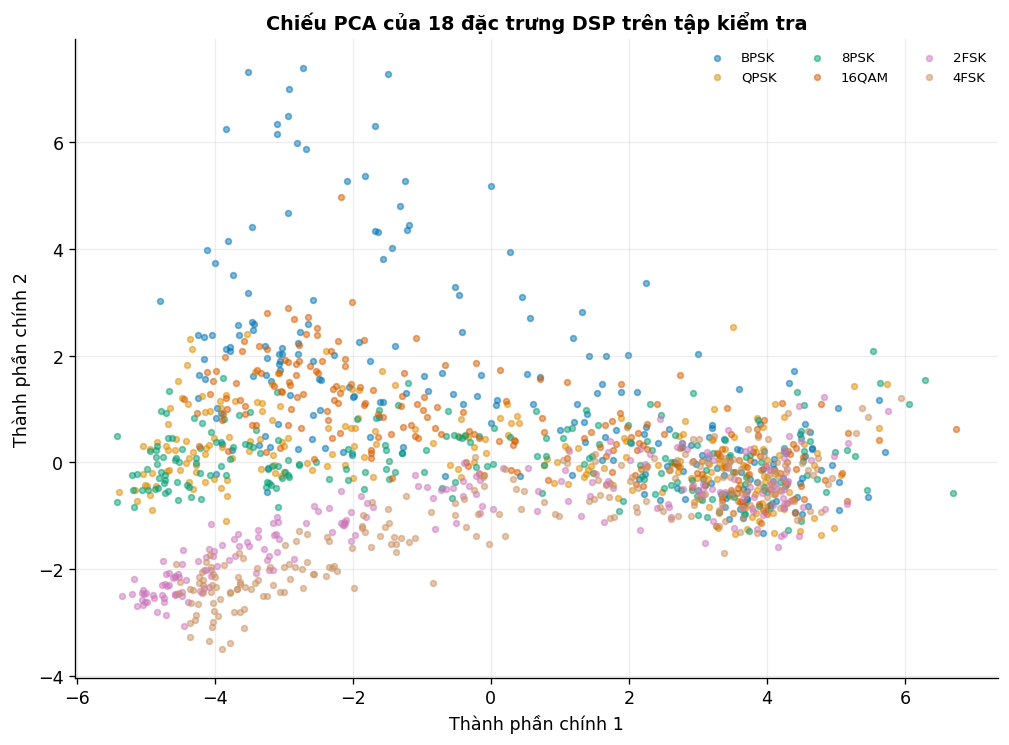

In [9]:
pca = Pipeline([("scale", StandardScaler()), ("pca", PCA(n_components=2, random_state=SEED))])
embedding = pca.fit_transform(X_feat[idx_test])
fig, ax = plt.subplots(figsize=(8.3, 6.1), constrained_layout=True)
for class_id, kind in enumerate(CFG.classes):
    mask = y[idx_test] == class_id
    ax.scatter(embedding[mask, 0], embedding[mask, 1], s=12, alpha=0.50, label=kind)
ax.set_title("Chiếu PCA của 18 đặc trưng DSP trên tập kiểm tra", weight="bold")
ax.set_xlabel("Thành phần chính 1")
ax.set_ylabel("Thành phần chính 2")
ax.legend(ncol=3, fontsize=8)
fig.savefig(FIG_DIR / "05_feature_pca.png", bbox_inches="tight")
plt.show()

## 6. CNN 1-D gọn nhẹ trên biểu diễn DSP tuần tự

Tensor đầu vào có bốn kênh: $I[n]$, $Q[n]$, $|x[n]|$ và
$\sin(\Delta\phi[n])$. Sai phân pha giúp giảm nhạy với pha ban đầu; I/Q vẫn giữ
thông tin dấu và quỹ đạo tín hiệu. CNN sử dụng ba tầng tích chập, pooling và
global average pooling; số tham số được báo cáo thay vì gọi chung là “nhẹ”.

Với một lớp tích chập 1-D, đặc trưng thứ $k$ là

$$y_k[n] = \sigma\!\left(b_k + \sum_c\sum_{m=0}^{M-1}w_{k,c}[m]x_c[n-m]\right).$$

In [10]:
def cnn_tensor(x_complex: np.ndarray) -> np.ndarray:
    z = x_complex / np.sqrt(np.mean(np.abs(x_complex) ** 2, axis=1, keepdims=True) + 1e-12)
    dphase = np.angle(z[:, 1:] * np.conj(z[:, :-1]))
    dphase = np.pad(dphase, ((0, 0), (1, 0)), mode="edge")
    return np.stack([z.real, z.imag, np.abs(z), np.sin(dphase)], axis=1).astype(np.float32)


X_cnn = cnn_tensor(X)
X_cnn.shape

(6600, 4, 256)

In [11]:
class CompactIQCNN(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(4, 32, kernel_size=9, padding=4, bias=False),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Conv1d(32, 32, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.10),
            nn.Conv1d(32, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64, 64, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.15),
            nn.Conv1d(64, 96, kernel_size=5, padding=2, bias=False),
            nn.BatchNorm1d(96),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(96, 64),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(64, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CompactIQCNN(N_CLASSES).to(device)
parameter_count = sum(p.numel() for p in model.parameters())
print(model)
print(f"Tổng số tham số học được: {parameter_count:,}")


def make_loader(indices: np.ndarray, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(torch.from_numpy(X_cnn[indices]), torch.from_numpy(y[indices]))
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        dataset,
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=0,
        generator=generator if shuffle else None,
    )


train_loader = make_loader(idx_train, True)
val_loader = make_loader(idx_val, False)
test_loader = make_loader(idx_test, False)


@torch.no_grad()
def evaluate_loader(net: nn.Module, loader: DataLoader) -> tuple[float, float, np.ndarray]:
    net.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    labels: list[np.ndarray] = []
    probs: list[np.ndarray] = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = net(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        labels.append(yb.cpu().numpy())
        probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    y_true = np.concatenate(labels)
    probability = np.concatenate(probs)
    pred = probability.argmax(axis=1)
    return total_loss / len(y_true), accuracy_score(y_true, pred), probability


optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
criterion = nn.CrossEntropyLoss(label_smoothing=0.03)
history: list[dict[str, float]] = []
best_state: dict[str, torch.Tensor] | None = None
best_val_loss = float("inf")
epochs_without_improvement = 0
train_start = time.perf_counter()

for epoch in range(1, CFG.max_epochs + 1):
    model.train()
    running_loss = 0.0
    seen = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        running_loss += loss.item() * len(yb)
        seen += len(yb)
    train_loss = running_loss / seen
    val_loss, val_acc, _ = evaluate_loader(model, val_loader)
    scheduler.step(val_loss)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
    )
    print(
        f"Epoch {epoch:02d} | train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f} | val acc {val_acc:.4f}"
    )
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CFG.patience:
            print("Dừng sớm: validation loss không cải thiện.")
            break

cnn_train_seconds = time.perf_counter() - train_start
assert best_state is not None
model.load_state_dict(best_state)
model.to(device)
test_loss, cnn_accuracy, cnn_prob = evaluate_loader(model, test_loader)
cnn_pred = cnn_prob.argmax(axis=1)
cnn_macro_f1 = f1_score(y[idx_test], cnn_pred, average="macro")
print(
    f"CNN tốt nhất: accuracy={cnn_accuracy:.4f}, macro-F1={cnn_macro_f1:.4f}, "
    f"test loss={test_loss:.4f}, train={cnn_train_seconds:.2f} s"
)

CompactIQCNN(
  (features): Sequential(
    (0): Conv1d(4, 32, kernel_size=(9,), stride=(1,), padding=(4,), bias=False)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): GELU(approximate='none')
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.1, inplace=False)
    (8): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (12): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): GELU(approximate='none')
    (14): MaxPool1

Epoch 01 | train loss 1.4806 | val loss 2.0684 | val acc 0.2247


Epoch 02 | train loss 1.1430 | val loss 1.1854 | val acc 0.5316


Epoch 03 | train loss 1.0250 | val loss 0.9144 | val acc 0.5669


Epoch 04 | train loss 0.9260 | val loss 1.0873 | val acc 0.5316


...

Epoch 15 | train loss 0.6039 | val loss 0.6256 | val acc 0.7235


Epoch 16 | train loss 0.5981 | val loss 0.6777 | val acc 0.7210


Epoch 17 | train loss 0.5864 | val loss 0.6111 | val acc 0.7412


Epoch 18 | train loss 0.5696 | val loss 0.6375 | val acc 0.7374


Epoch 19 | train loss 0.5788 | val loss 0.6521 | val acc 0.7374
Dừng sớm: validation loss không cải thiện.
CNN tốt nhất: accuracy=0.7182, macro-F1=0.7201, test loss=0.6299, train=34.98 s


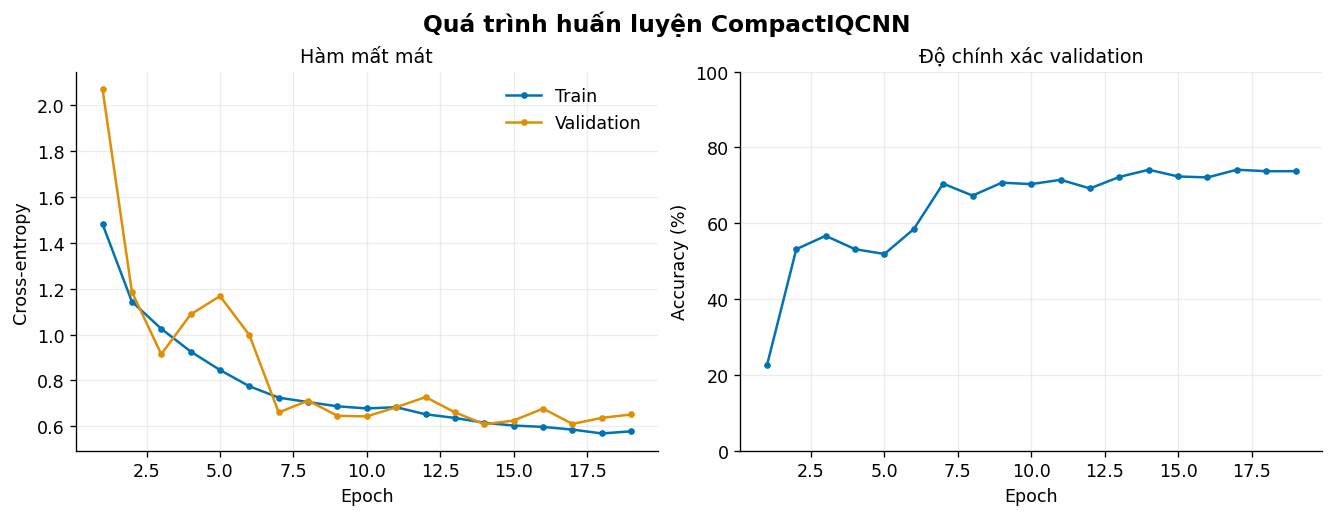

In [12]:
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", ms=3, label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", ms=3, label="Validation")
axes[0].set_title("Hàm mất mát")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy")
axes[0].legend()
axes[1].plot(history_df["epoch"], history_df["val_accuracy"] * 100, marker="o", ms=3)
axes[1].set_title("Độ chính xác validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
fig.suptitle("Quá trình huấn luyện CompactIQCNN", fontsize=14, weight="bold")
fig.savefig(FIG_DIR / "06_training_curves.png", bbox_inches="tight")
plt.show()

## 7. Đánh giá mô hình và tổ hợp xác suất

Hai mô hình có sai số khác nhau nên notebook khảo sát phép tổ hợp đơn giản
$p_{hybrid}=\alpha p_{CNN}+(1-\alpha)p_{RF}$. Hệ số $\alpha$ được chọn **chỉ trên
validation**, sau đó khóa lại trước khi đánh giá tập test. Điều này tránh chọn hệ
số theo kết quả test.

In [13]:
rf_val_prob = rf_model.predict_proba(X_feat[idx_val])
_, _, cnn_val_prob = evaluate_loader(model, val_loader)
alpha_grid = np.linspace(0.0, 1.0, 21)
alpha_scores = []
for alpha in alpha_grid:
    val_pred = (alpha * cnn_val_prob + (1.0 - alpha) * rf_val_prob).argmax(axis=1)
    alpha_scores.append(f1_score(y[idx_val], val_pred, average="macro"))
best_alpha = float(alpha_grid[int(np.argmax(alpha_scores))])
hybrid_prob = best_alpha * cnn_prob + (1.0 - best_alpha) * rf_prob
hybrid_pred = hybrid_prob.argmax(axis=1)
hybrid_accuracy = accuracy_score(y[idx_test], hybrid_pred)
hybrid_macro_f1 = f1_score(y[idx_test], hybrid_pred, average="macro")
print(f"alpha chọn trên validation = {best_alpha:.2f}")
print(f"Hybrid: accuracy={hybrid_accuracy:.4f}, macro-F1={hybrid_macro_f1:.4f}")


def wilson_interval(correct: int, total: int, z: float = 1.96) -> tuple[float, float]:
    p = correct / total
    den = 1.0 + z**2 / total
    center = (p + z**2 / (2 * total)) / den
    half = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / den
    return center - half, center + half


metrics_rows = []
for name, pred in (("RF–DSP", rf_pred), ("CNN–DSP", cnn_pred), ("Hybrid", hybrid_pred)):
    acc = accuracy_score(y[idx_test], pred)
    f1 = f1_score(y[idx_test], pred, average="macro")
    low, high = wilson_interval(int(np.sum(pred == y[idx_test])), len(idx_test))
    metrics_rows.append(
        {
            "Mô hình": name,
            "Accuracy": acc,
            "Macro-F1": f1,
            "CI95 thấp": low,
            "CI95 cao": high,
        }
    )
metrics_table = pd.DataFrame(metrics_rows)
display(metrics_table.style.format({c: "{:.4f}" for c in metrics_table.columns if c != "Mô hình"}))

alpha chọn trên validation = 0.55
Hybrid: accuracy=0.7348, macro-F1=0.7340


,Mô hình,Accuracy,Macro-F1,CI95 thấp,CI95 cao
0,RF–DSP,0.5848,0.5817,0.5581,0.6111
1,CNN–DSP,0.7182,0.7201,0.6933,0.7418
2,Hybrid,0.7348,0.7340,0.7104,0.7580


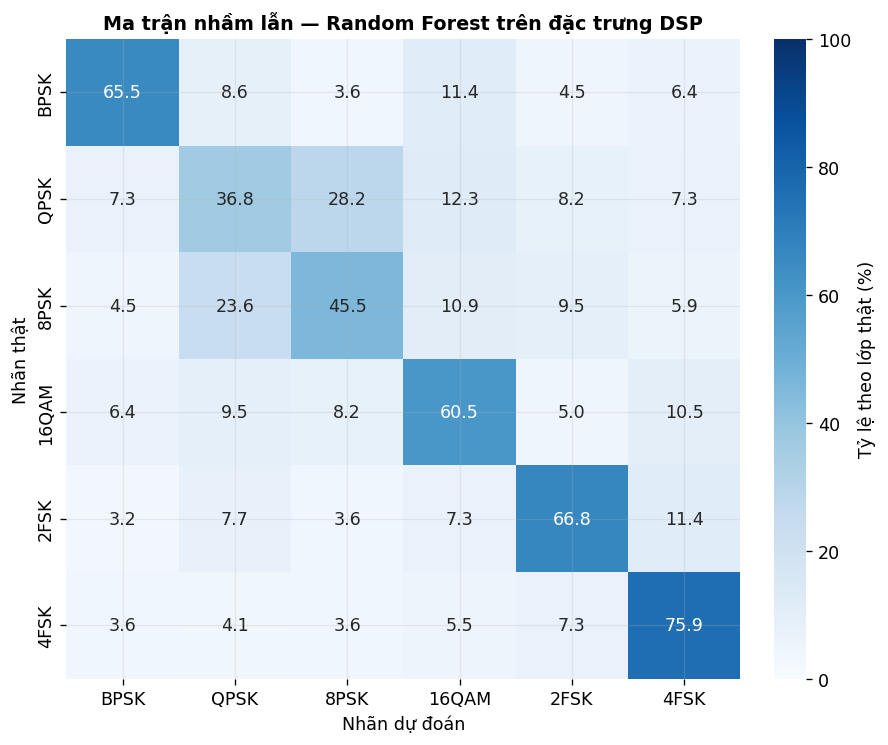

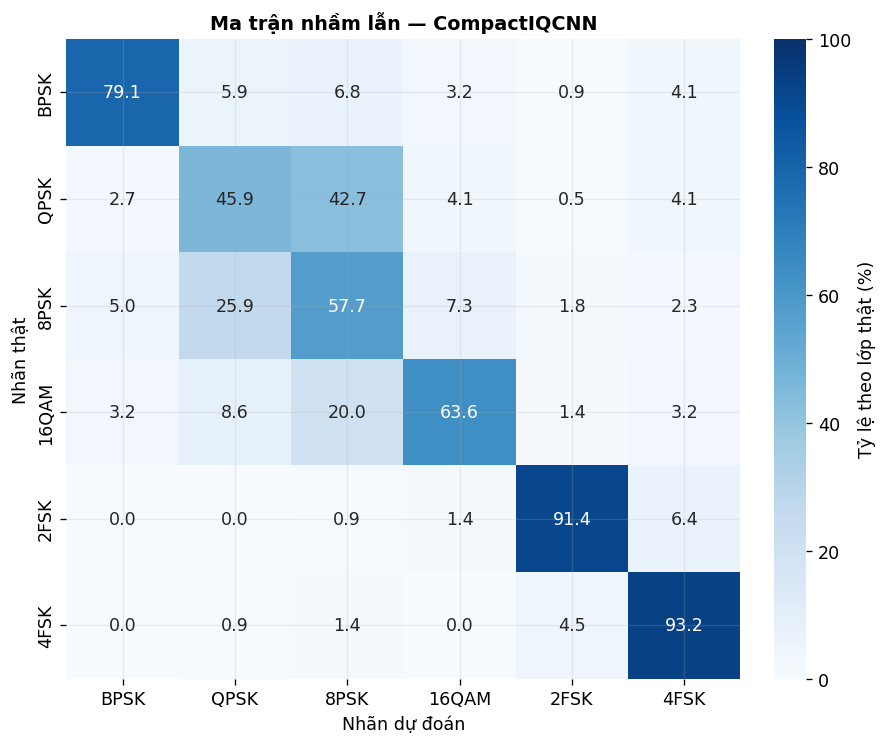

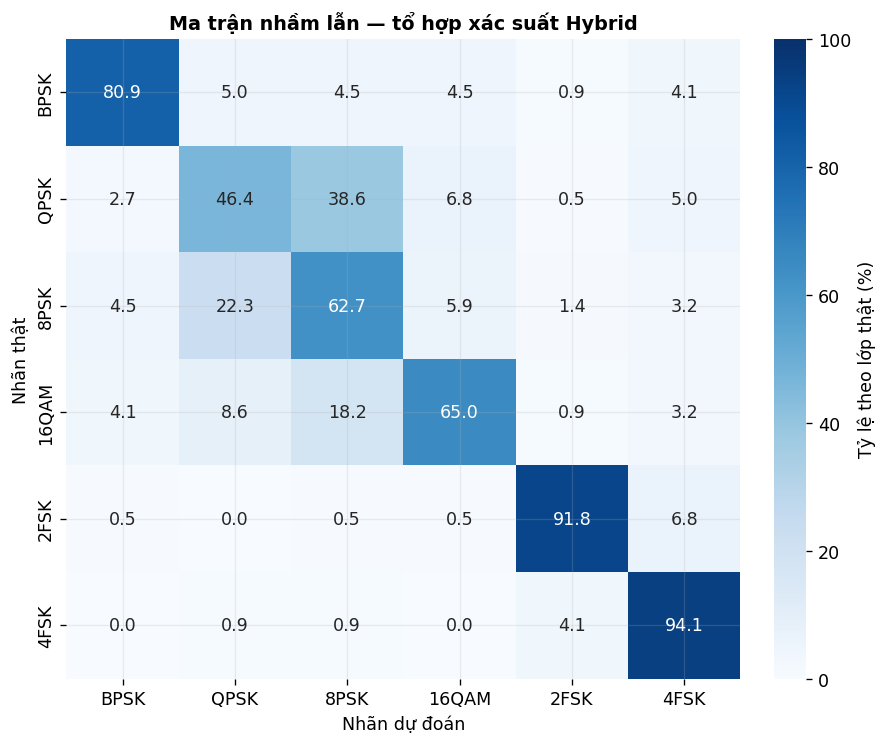

In [14]:
def plot_confusion(pred: np.ndarray, title: str, filename: str) -> None:
    cm = confusion_matrix(y[idx_test], pred, normalize="true") * 100
    fig, ax = plt.subplots(figsize=(7.3, 6.1), constrained_layout=True)
    sns.heatmap(
        cm,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        vmin=0,
        vmax=100,
        xticklabels=CFG.classes,
        yticklabels=CFG.classes,
        cbar_kws={"label": "Tỷ lệ theo lớp thật (%)"},
        ax=ax,
    )
    ax.set_xlabel("Nhãn dự đoán")
    ax.set_ylabel("Nhãn thật")
    ax.set_title(title, weight="bold")
    fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()


plot_confusion(rf_pred, "Ma trận nhầm lẫn — Random Forest trên đặc trưng DSP", "07_confusion_rf.png")
plot_confusion(cnn_pred, "Ma trận nhầm lẫn — CompactIQCNN", "08_confusion_cnn.png")
plot_confusion(hybrid_pred, "Ma trận nhầm lẫn — tổ hợp xác suất Hybrid", "09_confusion_hybrid.png")

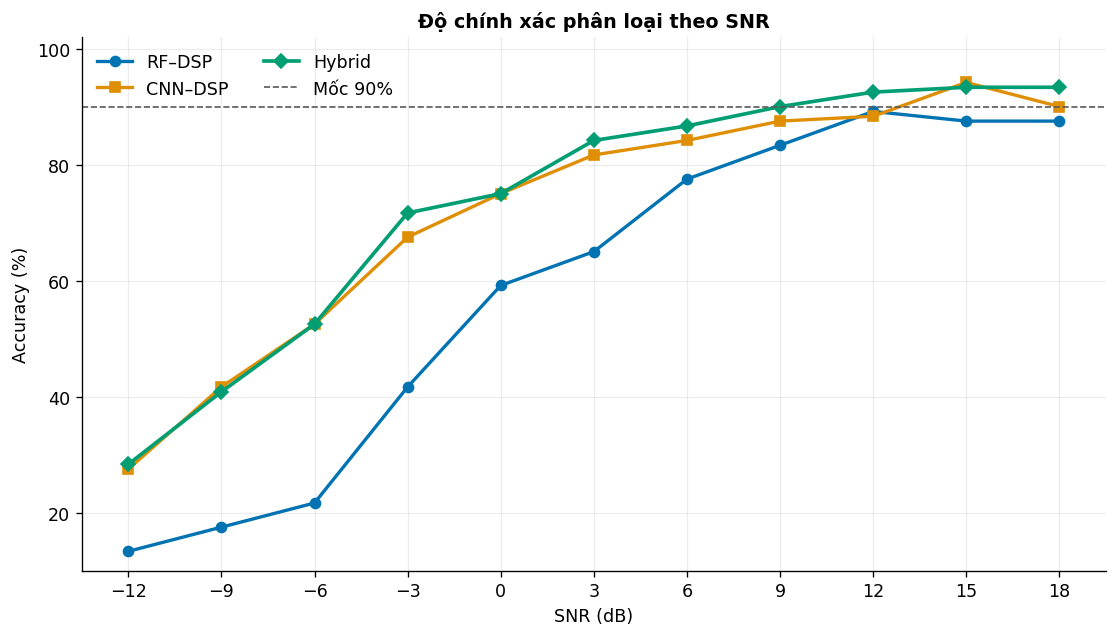

In [15]:
def accuracy_by_snr(pred: np.ndarray) -> np.ndarray:
    result = []
    for snr_db in CFG.snr_db:
        mask = snr_values[idx_test] == snr_db
        result.append(accuracy_score(y[idx_test][mask], pred[mask]))
    return np.array(result)


snr_rf = accuracy_by_snr(rf_pred)
snr_cnn = accuracy_by_snr(cnn_pred)
snr_hybrid = accuracy_by_snr(hybrid_pred)
fig, ax = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)
ax.plot(CFG.snr_db, 100 * snr_rf, marker="o", lw=2, label="RF–DSP")
ax.plot(CFG.snr_db, 100 * snr_cnn, marker="s", lw=2, label="CNN–DSP")
ax.plot(CFG.snr_db, 100 * snr_hybrid, marker="D", lw=2.2, label="Hybrid")
ax.axhline(90, color="0.35", ls="--", lw=1, label="Mốc 90%")
ax.set_xticks(CFG.snr_db)
ax.set_ylim(10, 102)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Độ chính xác phân loại theo SNR", weight="bold")
ax.legend(ncol=2)
fig.savefig(FIG_DIR / "10_accuracy_vs_snr.png", bbox_inches="tight")
plt.show()

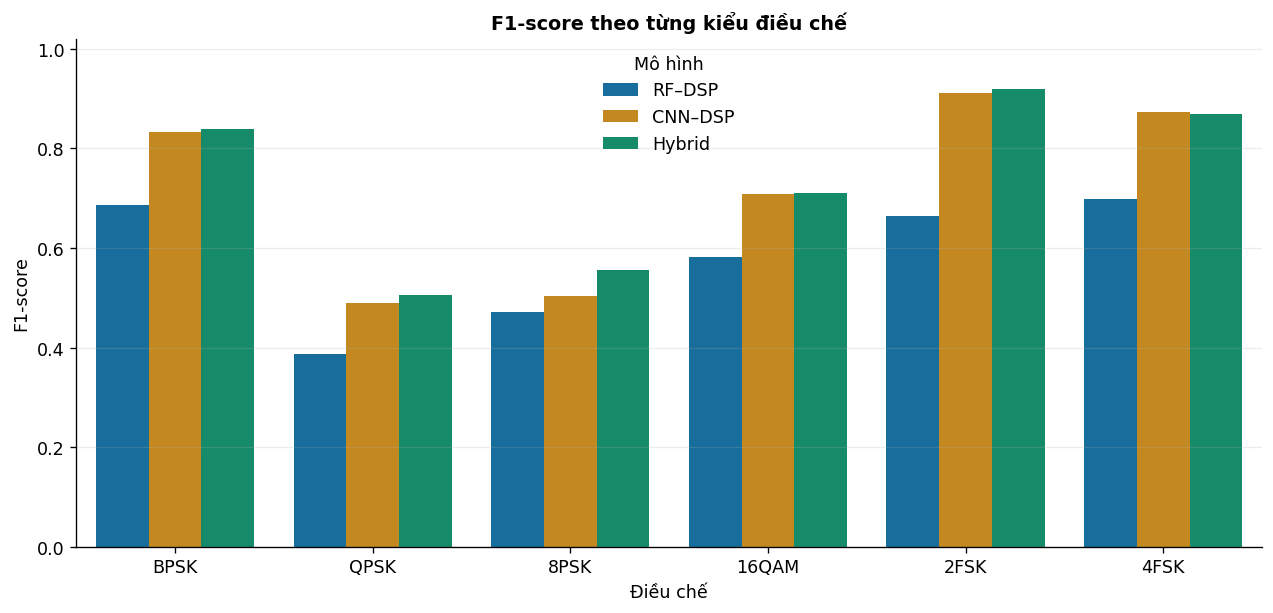

In [16]:
per_class_rows = []
for name, pred in (("RF–DSP", rf_pred), ("CNN–DSP", cnn_pred), ("Hybrid", hybrid_pred)):
    scores = f1_score(y[idx_test], pred, average=None)
    per_class_rows.extend(
        {"Mô hình": name, "Điều chế": kind, "F1": score}
        for kind, score in zip(CFG.classes, scores)
    )
per_class_df = pd.DataFrame(per_class_rows)
fig, ax = plt.subplots(figsize=(10.5, 5.0), constrained_layout=True)
sns.barplot(data=per_class_df, x="Điều chế", y="F1", hue="Mô hình", ax=ax)
ax.set_ylim(0, 1.02)
ax.set_ylabel("F1-score")
ax.set_title("F1-score theo từng kiểu điều chế", weight="bold")
fig.savefig(FIG_DIR / "11_f1_by_class.png", bbox_inches="tight")
plt.show()

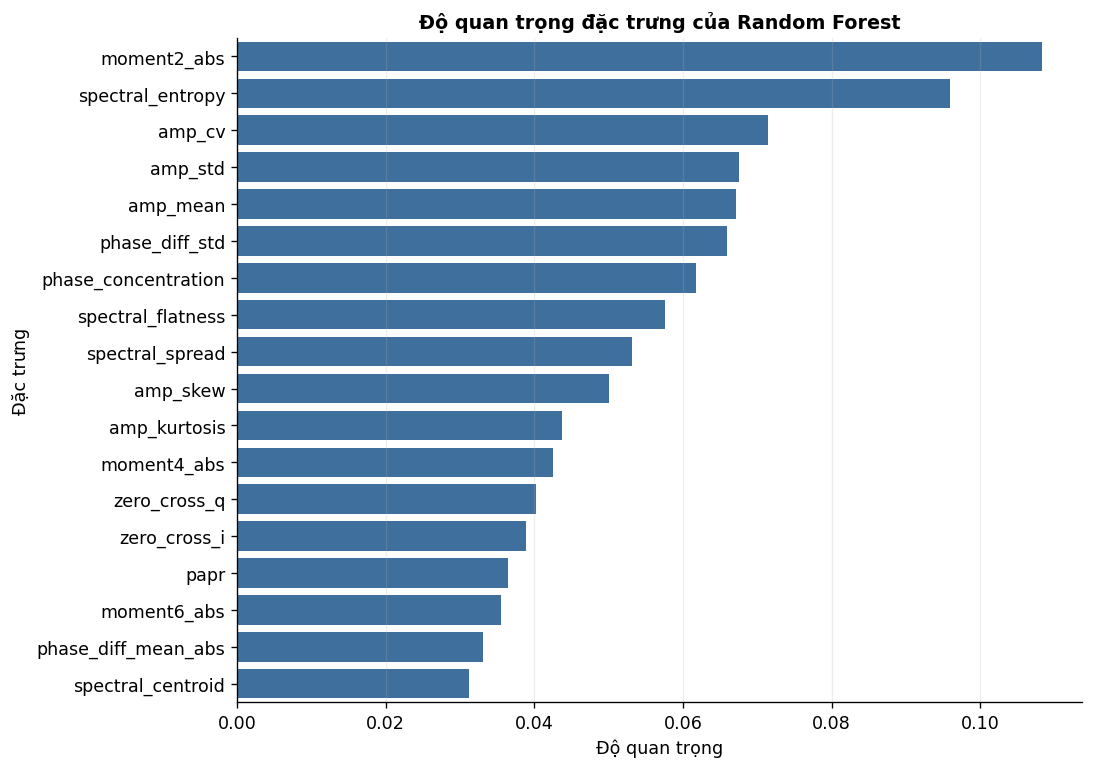

,Đặc trưng,Độ quan trọng
0,moment2_abs,0.108266
1,spectral_entropy,0.095886
2,amp_cv,0.071437
3,amp_std,0.067544
4,amp_mean,0.067143
5,phase_diff_std,0.065894
6,phase_concentration,0.061681
7,spectral_flatness,0.057611
8,spectral_spread,0.053093
9,amp_skew,0.050059


In [17]:
importance = rf_model.named_steps["rf"].feature_importances_
order = np.argsort(importance)[::-1]
importance_df = pd.DataFrame(
    {"Đặc trưng": np.array(FEATURE_NAMES)[order], "Độ quan trọng": importance[order]}
)
fig, ax = plt.subplots(figsize=(9, 6.3), constrained_layout=True)
sns.barplot(data=importance_df, y="Đặc trưng", x="Độ quan trọng", color="#2E6FAD", ax=ax)
ax.set_title("Độ quan trọng đặc trưng của Random Forest", weight="bold")
fig.savefig(FIG_DIR / "12_feature_importance.png", bbox_inches="tight")
plt.show()
display(importance_df.head(10))

## 8. Độ trễ suy luận và demo một khung tín hiệu

Độ trễ được đo theo batch trên đúng máy đang chạy notebook, có warm-up và lặp
nhiều lần. Đây là số đo kỹ thuật cục bộ, không được diễn giải như benchmark cho
phần cứng nhúng hay SDR thời gian thực.

In [18]:
@torch.no_grad()
def measure_cnn_latency(batch: np.ndarray, repeats: int = 30) -> float:
    tensor = torch.from_numpy(batch).to(device)
    model.eval()
    for _ in range(5):
        _ = model(tensor)
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(repeats):
        _ = model(tensor)
    if device.type == "cuda":
        torch.cuda.synchronize()
    return 1e3 * (time.perf_counter() - start) / (repeats * len(batch))


latency_batch = X_cnn[idx_test[:256]]
cnn_latency_ms = measure_cnn_latency(latency_batch)
start = time.perf_counter()
for _ in range(30):
    _ = rf_model.predict_proba(X_feat[idx_test[:256]])
rf_latency_ms = 1e3 * (time.perf_counter() - start) / (30 * 256)
print(f"Độ trễ trung bình RF–DSP (không gồm trích đặc trưng): {rf_latency_ms:.4f} ms/khung")
print(f"Độ trễ trung bình CNN–DSP ({device.type.upper()}): {cnn_latency_ms:.4f} ms/khung")

Độ trễ trung bình RF–DSP (không gồm trích đặc trưng): 0.1963 ms/khung
Độ trễ trung bình CNN–DSP (CPU): 0.0626 ms/khung


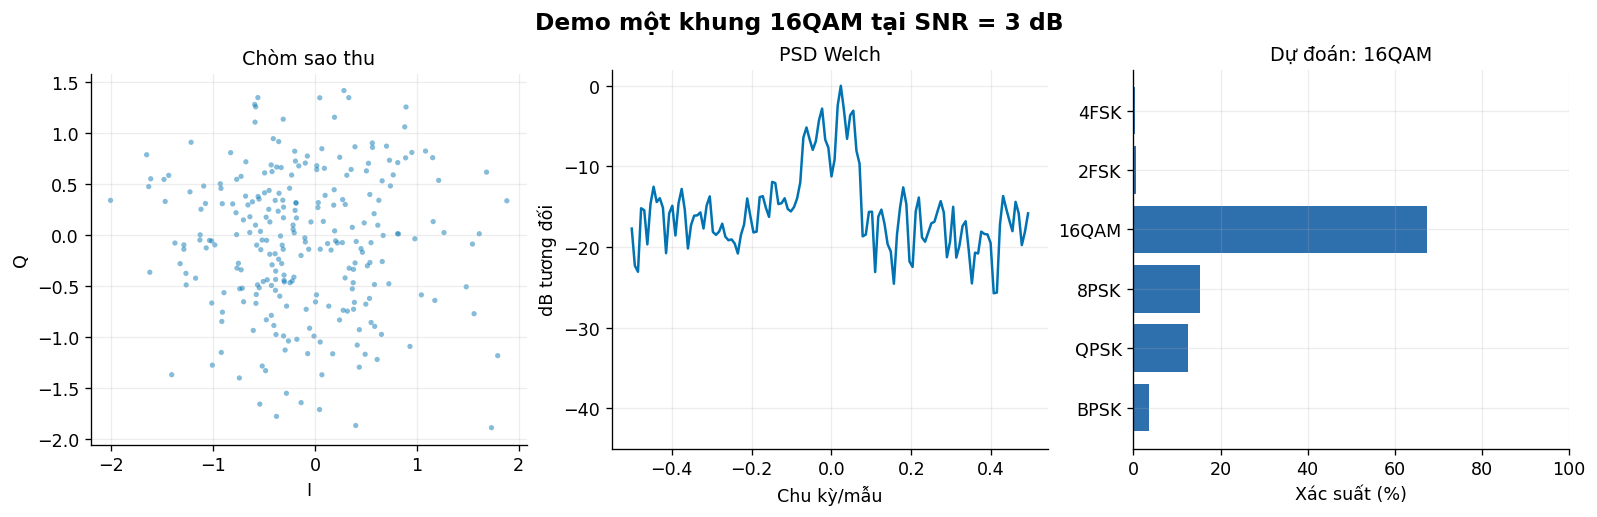

Nhãn thật: 16QAM | Nhãn dự đoán: 16QAM


In [19]:
demo_kind = "16QAM"
demo_snr = 3
demo_rng = np.random.default_rng(SEED + 909)
demo_z = apply_channel(generate_clean_frame(demo_kind, demo_rng), demo_snr, demo_rng)
demo_feat = dsp_features(demo_z)[None, :]
demo_tensor = torch.from_numpy(cnn_tensor(demo_z[None, :])).to(device)
model.eval()
with torch.no_grad():
    demo_cnn_prob = torch.softmax(model(demo_tensor), dim=1).cpu().numpy()[0]
demo_rf_prob = rf_model.predict_proba(demo_feat)[0]
demo_hybrid_prob = best_alpha * demo_cnn_prob + (1 - best_alpha) * demo_rf_prob

freq, psd = signal.welch(demo_z, nperseg=128, noverlap=64, return_onesided=False)
freq = np.fft.fftshift(freq)
psd_db = 10 * np.log10(np.fft.fftshift(psd) + 1e-12)
psd_db -= psd_db.max()
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), constrained_layout=True)
axes[0].scatter(demo_z.real, demo_z.imag, s=10, alpha=0.48, edgecolors="none")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Chòm sao thu")
axes[0].set_xlabel("I")
axes[0].set_ylabel("Q")
axes[1].plot(freq, psd_db, lw=1.5)
axes[1].set_ylim(-45, 2)
axes[1].set_title("PSD Welch")
axes[1].set_xlabel("Chu kỳ/mẫu")
axes[1].set_ylabel("dB tương đối")
axes[2].barh(CFG.classes, 100 * demo_hybrid_prob, color="#2E6FAD")
axes[2].set_xlim(0, 100)
axes[2].set_xlabel("Xác suất (%)")
axes[2].set_title(f"Dự đoán: {CFG.classes[int(demo_hybrid_prob.argmax())]}")
fig.suptitle(f"Demo một khung {demo_kind} tại SNR = {demo_snr} dB", fontsize=14, weight="bold")
fig.savefig(FIG_DIR / "13_demo_prediction.png", bbox_inches="tight")
plt.show()
print(f"Nhãn thật: {demo_kind} | Nhãn dự đoán: {CFG.classes[int(demo_hybrid_prob.argmax())]}")

## 9. Lưu mô hình, số liệu và báo cáo tái lập

Notebook lưu trọng số CNN, pipeline RF, dự đoán tập test, lịch sử huấn luyện và
tệp JSON tổng hợp. Không lưu toàn bộ dữ liệu I/Q để tránh làm gói nộp nặng; dữ
liệu có thể sinh lại đúng bằng cấu hình và `SEED` đã ghi.

In [20]:
torch.save(
    {
        "state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
        "classes": CFG.classes,
        "config": asdict(CFG),
        "seed": SEED,
        "parameter_count": parameter_count,
    },
    ARTIFACT_DIR / "compact_iq_cnn.pt",
)
joblib.dump(rf_model, ARTIFACT_DIR / "rf_dsp_pipeline.joblib")
history_df.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)

prediction_df = pd.DataFrame(
    {
        "index": idx_test,
        "snr_db": snr_values[idx_test],
        "true_label": np.array(CFG.classes)[y[idx_test]],
        "rf_prediction": np.array(CFG.classes)[rf_pred],
        "cnn_prediction": np.array(CFG.classes)[cnn_pred],
        "hybrid_prediction": np.array(CFG.classes)[hybrid_pred],
    }
)
prediction_df.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)


def first_snr_at_or_above(values: np.ndarray, threshold: float = 0.90) -> int | None:
    for snr_db, value in zip(CFG.snr_db, values):
        if value >= threshold:
            return int(snr_db)
    return None


metrics = {
    "project": "DEEPDSP-AMC",
    "student": {"name": "Lương Hải Long", "id": "22207056"},
    "course": "Thực hành Xử lý tín hiệu số - 24DTV_DKD2",
    "instructor": "ThS. Huỳnh Quốc Thịnh",
    "seed": SEED,
    "config": asdict(CFG),
    "split_sizes": {"train": len(idx_train), "validation": len(idx_val), "test": len(idx_test)},
    "rf": {
        "accuracy": rf_accuracy,
        "macro_f1": rf_macro_f1,
        "train_seconds": rf_train_seconds,
        "latency_ms_per_frame_excluding_features": rf_latency_ms,
    },
    "cnn": {
        "accuracy": cnn_accuracy,
        "macro_f1": cnn_macro_f1,
        "train_seconds": cnn_train_seconds,
        "latency_ms_per_frame": cnn_latency_ms,
        "parameter_count": parameter_count,
        "epochs_ran": len(history_df),
    },
    "hybrid": {
        "alpha_cnn_selected_on_validation": best_alpha,
        "accuracy": hybrid_accuracy,
        "macro_f1": hybrid_macro_f1,
        "accuracy_by_snr": {str(k): float(v) for k, v in zip(CFG.snr_db, snr_hybrid)},
        "snr_for_90pct_accuracy_db": first_snr_at_or_above(snr_hybrid),
    },
    "environment": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": np.__version__,
        "scipy": scipy.__version__,
        "scikit_learn": sklearn.__version__,
        "torch": torch.__version__,
        "device": str(device),
    },
}
(ARTIFACT_DIR / "metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(metrics["hybrid"], ensure_ascii=False, indent=2))

{
  "alpha_cnn_selected_on_validation": 0.55,
  "accuracy": 0.7348484848484849,
  "macro_f1": 0.7339569603511245,
  "accuracy_by_snr": {
    "-12": 0.2833333333333333,
    "-9": 0.4083333333333333,
    "-6": 0.525,
    "-3": 0.7166666666666667,
    "0": 0.75,
    "3": 0.8416666666666667,
    "6": 0.8666666666666667,
    "9": 0.9,
    "12": 0.925,
    "15": 0.9333333333333333,
    "18": 0.9333333333333333
  },
  "snr_for_90pct_accuracy_db": 9
}


## 10. Kết luận kỹ thuật

Kết luận bên dưới được tạo từ số đo thực của lần chạy này. Khi thay cấu hình hoặc
môi trường, cần chạy lại toàn bộ notebook và không được giữ nguyên con số cũ.

In [21]:
delta_f1 = hybrid_macro_f1 - rf_macro_f1
threshold_snr = first_snr_at_or_above(snr_hybrid)
threshold_text = (
    f"{threshold_snr} dB" if threshold_snr is not None else "chưa đạt trong dải khảo sát"
)
display(
    Markdown(
        f"""
**Kết quả chính.** Trên tập test độc lập gồm **{len(idx_test):,}** khung, mô hình
RF–DSP đạt accuracy **{rf_accuracy*100:.2f}%** và macro-F1 **{rf_macro_f1:.4f}**;
CNN–DSP đạt accuracy **{cnn_accuracy*100:.2f}%** và macro-F1 **{cnn_macro_f1:.4f}**.
Tổ hợp xác suất (hệ số CNN $\\alpha={best_alpha:.2f}$ chọn trên validation) đạt
accuracy **{hybrid_accuracy*100:.2f}%**, macro-F1 **{hybrid_macro_f1:.4f}**, chênh
**{delta_f1:+.4f}** macro-F1 so với baseline. Mốc accuracy 90% của hybrid:
**{threshold_text}**.

**Giới hạn.** Dữ liệu là mô phỏng có kiểm soát, kênh đa đường nhẹ và một lần huấn
luyện với hạt giống cố định. Kết quả chưa chứng minh khả năng tổng quát cho phần
cứng SDR, kênh fading mạnh, nhiễu đồng kênh hoặc sai lệch tốc độ lấy mẫu. Bước phát
triển hợp lý là thu I/Q thật bằng SDR và đánh giá chéo theo phiên thu.
"""
    )
)


**Kết quả chính.** Trên tập test độc lập gồm **1,320** khung, mô hình
RF–DSP đạt accuracy **58.48%** và macro-F1 **0.5817**;
CNN–DSP đạt accuracy **71.82%** và macro-F1 **0.7201**.
Tổ hợp xác suất (hệ số CNN $\alpha=0.55$ chọn trên validation) đạt
accuracy **73.48%**, macro-F1 **0.7340**, chênh
**+0.1523** macro-F1 so với baseline. Mốc accuracy 90% của hybrid:
**9 dB**.

**Giới hạn.** Dữ liệu là mô phỏng có kiểm soát, kênh đa đường nhẹ và một lần huấn
luyện với hạt giống cố định. Kết quả chưa chứng minh khả năng tổng quát cho phần
cứng SDR, kênh fading mạnh, nhiễu đồng kênh hoặc sai lệch tốc độ lấy mẫu. Bước phát
triển hợp lý là thu I/Q thật bằng SDR và đánh giá chéo theo phiên thu.


In [22]:
required_outputs = [
    FIG_DIR / f"{i:02d}_{name}.png"
    for i, name in [
        (1, "iq_time_gallery"),
        (2, "constellation_gallery"),
        (3, "psd_gallery"),
        (4, "dataset_balance"),
        (5, "feature_pca"),
        (6, "training_curves"),
        (7, "confusion_rf"),
        (8, "confusion_cnn"),
        (9, "confusion_hybrid"),
        (10, "accuracy_vs_snr"),
        (11, "f1_by_class"),
        (12, "feature_importance"),
        (13, "demo_prediction"),
    ]
]
required_outputs += [
    ARTIFACT_DIR / "metrics.json",
    ARTIFACT_DIR / "training_history.csv",
    ARTIFACT_DIR / "test_predictions.csv",
    ARTIFACT_DIR / "compact_iq_cnn.pt",
    ARTIFACT_DIR / "rf_dsp_pipeline.joblib",
]
missing = [str(path) for path in required_outputs if not path.exists() or path.stat().st_size == 0]
assert not missing, f"Thiếu đầu ra: {missing}"
print(f"PASS — {len(required_outputs)} đầu ra bắt buộc đã tồn tại và khác rỗng.")

PASS — 18 đầu ra bắt buộc đã tồn tại và khác rỗng.
